In [ ]:
import pandas as pd 
import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import

In [39]:
df = pd.read_csv("../data/raw/household_power.csv")

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_19872\454742109.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/household_power.csv")


In [40]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Global_active_power : column represents the total "real" power being actively consumed by the entire household at that specific minute

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [42]:
df.describe(include='all')

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2.049280e+06
unique,1442,1440,6534,896,5168,377,153,145,NaN
top,25/11/2010,17:24:00,?,0.000,?,1.000,0.000,0.000,NaN
freq,1440,1442,25979,472786,25979,169406,1840611,1408274,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.458447e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.437154e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+01


In [43]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [44]:
df["Sub_metering_3"].isnull().sum()

np.int64(25979)

In [45]:
df.corr

<bound method DataFrame.corr of                Date      Time Global_active_power Global_reactive_power  \
0        16/12/2006  17:24:00               4.216                 0.418   
1        16/12/2006  17:25:00               5.360                 0.436   
2        16/12/2006  17:26:00               5.374                 0.498   
3        16/12/2006  17:27:00               5.388                 0.502   
4        16/12/2006  17:28:00               3.666                 0.528   
...             ...       ...                 ...                   ...   
2075254  26/11/2010  20:58:00               0.946                   0.0   
2075255  26/11/2010  20:59:00               0.944                   0.0   
2075256  26/11/2010  21:00:00               0.938                   0.0   
2075257  26/11/2010  21:01:00               0.934                   0.0   
2075258  26/11/2010  21:02:00               0.932                   0.0   

         Voltage Global_intensity Sub_metering_1 Sub_metering_2  \


In [46]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [47]:
X = df.drop(["Date","Time",] , axis=1)
y = df["Global_active_power"]

In [48]:
X

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...
2075254,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,0.934,0.0,239.7,3.8,0.0,0.0,0.0


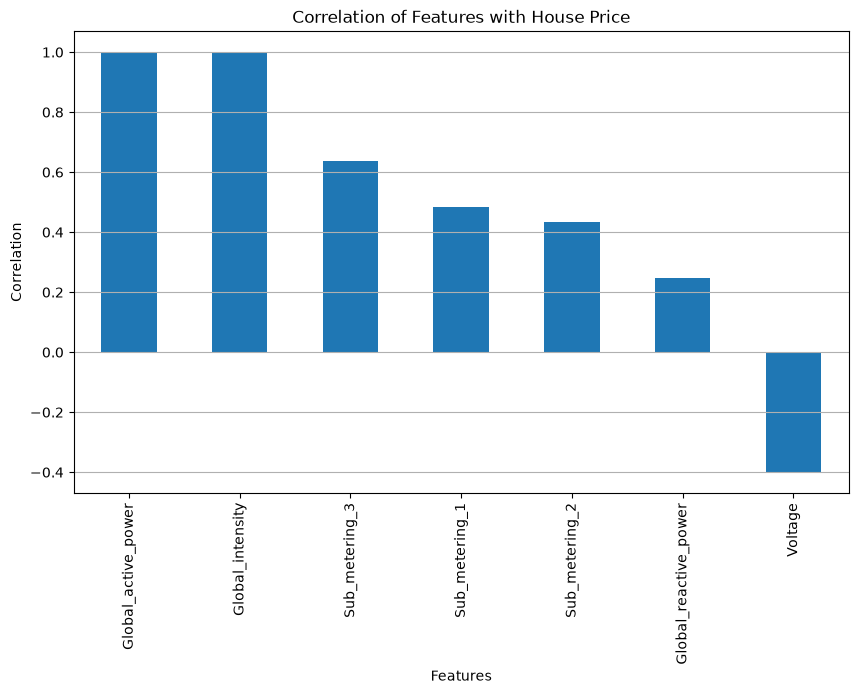

<Figure size 640x480 with 0 Axes>

In [49]:
df_numeric = df.drop(["Date","Time"], axis=1).apply(pd.to_numeric, errors='coerce')
corr = df_numeric.corr()["Global_active_power"].sort_values(ascending=False)
plt.figure(figsize=(10,6))
corr.plot(kind="bar")
plt.title("Correlation of Features with House Price")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.grid(axis="y")
plt.show()

plt.savefig('../Reports/outputs/correlation_plot.png', bbox_inches='tight')

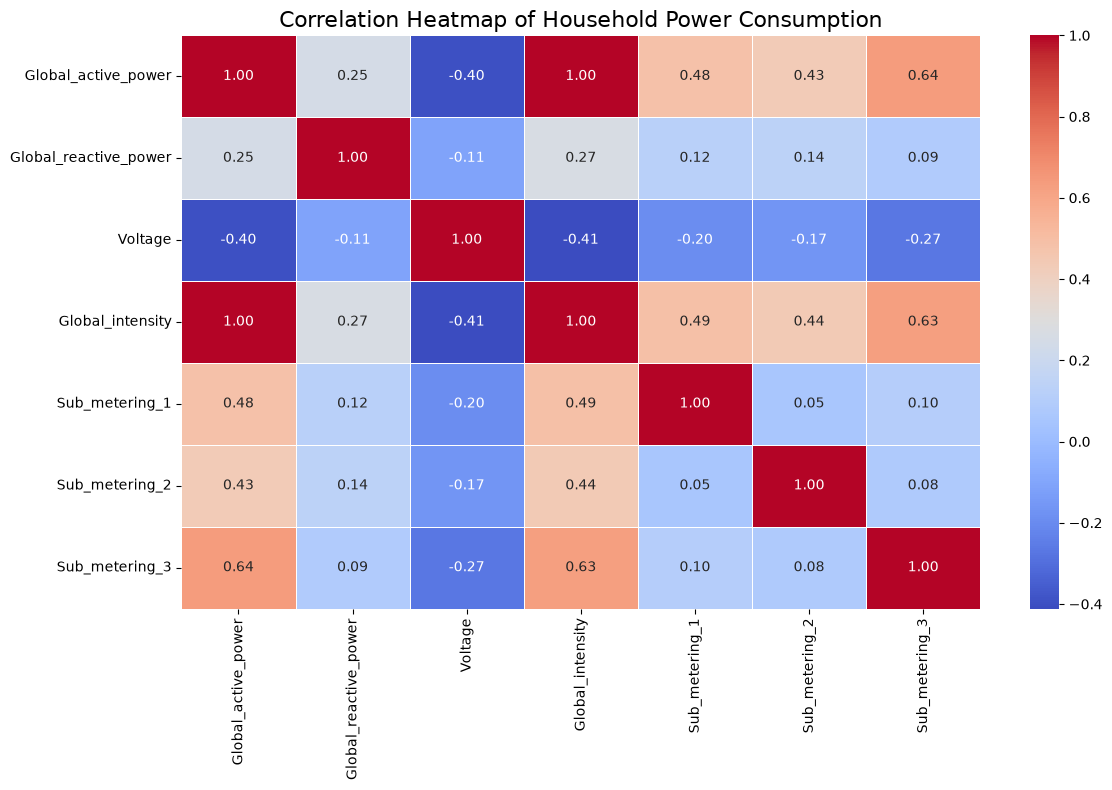

<Figure size 640x480 with 0 Axes>

In [50]:
df_numeric = df.drop(["Date", "Time"], axis=1)

# 2. CRITICAL STEP: The raw UCI dataset uses '?' for missing values, 
# which makes pandas treat the columns as strings. 
# We must force them to be numbers before doing math.
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')

# 3. Calculate the correlation matrix
corr_matrix = df_numeric.corr()

# 4. Plot the heatmap
plt.figure(figsize=(12, 8)) # Set the size of the graph

# sns.heatmap creates the visual. 
# annot=True puts the actual numbers in the boxes
# cmap="coolwarm" uses blue for negative correlation and red for positive
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Household Power Consumption", fontsize=16)
plt.tight_layout()
plt.show()

plt.savefig('../Reports/outputs/correlation_heatmap.png', bbox_inches='tight')

In [51]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [52]:
mean_col = X["Sub_metering_3"].mean()

X["Sub_metering_3"].fillna(mean_col, inplace=True)

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_19872\1953351019.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["Sub_metering_3"].fillna(mean_col, inplace=True)


In [53]:
X.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

all over form the data set there is the missing values in the column `Sub_metering_3`. So we can fill the missing values with the mean of the column.
target cln is -> `Global_active_power` . 
`votlage` have weak correlation with target so we drop form dataset with `date` and `time` . 